In [1]:
import sys
sys.path.insert(0, '..')

import json
import glob
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import numpy as np
import optax
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import polars as pl
import plotly.express as px
from grain import DataLoader
from grain.samplers import IndexSampler
from grain.transforms import Batch
from tqdm import tqdm

from src.dataset.flags import FlagDataset
from src.dataset.emojis import EmojiDataset
from src.dataset.celeba import CelebA
from src.model.siren import SIREN
from src.model.pm_nca import SIREN_NCA
from src.model.nca import NCA
from src.nn.backbone import init_backbone
# from src.training.checkpoint import CheckpointManager
from src.utils.core import seed_everything
from src.visualisation.utils import tile2d, strip


W0413 06:17:49.030480 2014575 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0413 06:17:49.034742 2013980 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


# Configuration

Set `MODELS_DIR` to the folder containing model run subfolders. Each subfolder must contain:
- `checkpoints/` — Orbax checkpoint directory (saved by `CheckpointManager`)
- `config.json` — model and dataset hyperparameters (see format below)

## `config.json` format

For a **SIREN** model:
```json
{
  "model_type": "siren",
  "dataset_name": "flags",
  "latent_size": 64,
  "siren_width": 64,
  "siren_depth": 2
}
```

For a **SIREN-NCA** model:
```json
{
  "model_type": "pmnca",
  "dataset_name": "flags",
  "latent_size": 64,
  "siren_width": 64,
  "siren_depth": 2,
  "hidden_state": 12,
  "update_width": 32,
  "update_depth": 1,
  "dev_steps": [20],
  "growing": false
}
```


In [2]:
MODELS_DIR = Path('../data/logs/emojis/')  # <-- folder containing model run subfolders
OUTPUT_SCALING = Path('../figures/scaling_analysis.pdf')
OUTPUT_RECONS  = Path('../figures/reconstruction_comparison.pdf')
SEED = 0
N_EXAMPLES = 8   # number of examples shown per panel in Figure 2
N_COLS     = 4   # columns in each tile grid


## Helper functions

In [20]:
def load_dataset(dataset_name: str):
    if dataset_name == 'flags':
        return FlagDataset('all', (32, 32))
    elif dataset_name == 'emojis':
        return EmojiDataset('../data/datasets/emojis', 'all', (64, 64), (0, 0))
    elif dataset_name == 'celeb_a':
        return CelebA('val', '../data/datasets/celeb_a', size=(64, 64), pad=(0, 0))
    else:
        raise ValueError(f'Unknown dataset: {dataset_name}')


def init_model(cfg: dict, key: jax.Array):
    dataset_name = cfg['dataset_name']
    latent_size  = cfg['latent_size']

    ds = load_dataset(dataset_name)
    input_shape = ds.input_shape

    enc_key, model_key = jr.split(key)
    backbone = init_backbone(input_shape, latent_size, variant=dataset_name, key=enc_key)

    model_type = cfg.get('model_type', 'siren')

    if model_type == 'siren':
        model = SIREN(
            input_shape=input_shape,
            encoder_backbone=backbone,
            latent_size=latent_size,
            siren_width=cfg['siren_width'],
            siren_depth=cfg['siren_depth'],
            key=model_key,
        )
    elif model_type == 'pmnca':
        dev_steps = cfg['dev_steps']
        model = SIREN_NCA(
            input_shape=input_shape,
            encoder_backbone=backbone,
            latent_size=latent_size,
            siren_width=cfg['siren_width'],
            siren_depth=cfg['siren_depth'],
            nca_hidden_size=cfg['hidden_state'],
            perception_type=cfg['perception_type'],
            update_width=cfg['update_width'],
            update_depth=cfg['update_depth'],
            update_prob=cfg.get('update_prob', 1.0),
            alive_index=3 if cfg.get('growing', False) else None,
            num_dev_steps=tuple(dev_steps) if isinstance(dev_steps, list) else (dev_steps,),
            key=model_key,
        )
    elif model_type == 'nca':
        backbone = init_backbone(input_shape, latent_size, variant=dataset_name, key=enc_key)
        dev_steps = cfg['dev_steps']
        model = NCA(
            input_shape=input_shape,
            hidden_size=cfg['hidden_state'],
            encoder_backbone=backbone,
            latent_size=latent_size,
            perception_type='sobel-with-laplace',
            update_width=cfg['update_width'],
            update_depth=cfg['update_depth'],
            update_prob=cfg.get('update_prob', 1.0),
            conditioning_mode=cfg.get('conditioning_model', 'concat'),  # type: ignore
            alive_index=3 if cfg.get('growing', False) else None,
            num_dev_steps=tuple(dev_steps) if isinstance(dev_steps, list) else (dev_steps,),
            key=jax_key,
        )
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    return model, ds


def count_params(model) -> int:
    return sum(x.size for x in jax.tree.leaves(model) if isinstance(x, jax.Array))
        # - sum(x.size for x in jax.tree.leaves(model.encoder) if isinstance(x, jax.Array))


def load_best_checkpoint(run_dir: Path, abstract_model):
    params, static = eqx.partition(abstract_model, eqx.is_array)
    with ocp.CheckpointManager(
        run_dir.absolute() / "checkpoints", 
        options=ocp.CheckpointManagerOptions(step_prefix="best")
    ) as mngr:
        params = mngr.restore(mngr.latest_step(), args=ocp.args.StandardRestore(params))
        return eqx.combine(params, static)


@eqx.filter_jit
def eval_batch_siren(model, inputs, key):
    preds, _, _ = jax.vmap(lambda x, k: model(x, k))(inputs, jr.split(key, len(inputs)))
    return jnp.sum(optax.l2_loss(preds, inputs))


@eqx.filter_jit
def eval_batch_pmnca(model, inputs, key):
    eval_max_steps = lambda x, k: model(x, k, steps=model.num_dev_steps[-1])
    preds, _ = jax.vmap(eval_max_steps)(inputs, jr.split(key, len(inputs)))
    return jnp.sum(optax.l2_loss(preds, inputs))


def compute_test_mse(model, dataset, model_type: str, key: jax.Array, batch_size: int = 4) -> float:
    loader = DataLoader(
        data_source=dataset,
        operations=[Batch(batch_size)],
        sampler=IndexSampler(len(dataset), shuffle=False, num_epochs=1),
    )
    eval_fn = eval_batch_siren if model_type == 'siren' else eval_batch_pmnca
    total_loss, total_n = 0.0, 0
    for batch in loader:
        inputs, _ = batch
        key, step_key = jr.split(key)
        total_loss += eval_fn(model, inputs, step_key).item()
        total_n += len(inputs)
    return total_loss / total_n


# Figure 0 — Test MSE vs Parameter Count

## Figure 0.2 — SIREN 1–5 Reconstructions

Load one example from each of five SIREN models and display them side by side.

In [ ]:
# Directories for the five SIREN models (must each contain config.json + checkpoints/)
SIREN_DIRS = [
    MODELS_DIR / 'siren' / 'siren-1',
    MODELS_DIR / 'siren' / 'siren-2',
    MODELS_DIR / 'siren' / 'siren-3',
    MODELS_DIR / 'siren' / 'siren-4',
    MODELS_DIR / 'siren' / 'siren-5',
    MODELS_DIR / 'siren' / 'siren-6',
    MODELS_DIR / 'siren' / 'siren-7',
    MODELS_DIR / 'siren' / 'siren-8',
]

SIREN_DIRS = [Path(glob.glob(str(f) + "/*")[0]) for f in SIREN_DIRS]

print(len(SIREN_DIRS))
    
SIREN_LABELS = ['DEPTH 1', 'DEPTH 2', 'DEPTH 3', 'DEPTH 4', 'DEPTH 5', 'DEPTH 6','DEPTH 7', 'DEPTH 8']
OUTPUT_SIREN_ROW = Path('../figures/siren_row.pdf')
SIREN_DIRS

In [ ]:
_, jax_key = seed_everything(SEED)

siren_recons = []  # one (C, H, W) reconstruction per model
for run_dir in SIREN_DIRS:
    cfg = json.loads((run_dir / 'config.json').read_text())
    jax_key, init_key, fwd_key = jr.split(jax_key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(run_dir, abstract_model)

    x = dataset[0][0]  # single example, shape (C, H, W)
    recon, _, _ = model(x, fwd_key)
    siren_recons.append(np.clip(np.asarray(recon), 0, 1))

OUTPUT_SIREN_ROW.parent.mkdir(parents=True, exist_ok=True)

n = len(siren_recons)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 2.5))
for ax, recon, label in zip(axes, siren_recons, SIREN_LABELS):
    img = recon.transpose(1, 2, 0)  # CHW -> HWC
    if img.shape[-1] == 4:
        alpha = img[..., 3:4]
        img = img[..., :3] * alpha + (1 - alpha)  # composite over white
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    strip(ax)

fig.tight_layout()
fig.savefig(OUTPUT_SIREN_ROW, bbox_inches='tight')
print(f'Figure saved to {OUTPUT_SIREN_ROW}')
plt.show()


In [ ]:
# Directories for the five SIREN models (must each contain config.json + checkpoints/)
# PMNCA_DIRS = [
#     MODELS_DIR / 'pmca-1',
#     MODELS_DIR / 'pmca-2',
#     MODELS_DIR / 'pmca-3',
#     MODELS_DIR / 'pmca-4',
#     MODELS_DIR / 'pmca-5',
# ]
PMNCA_DIRS = [
    MODELS_DIR / 'siren_nca' / 'inv-pmca-1',
    MODELS_DIR / 'siren_nca' / 'inv-pmca-2',
    MODELS_DIR / 'siren_nca' / 'inv-pmca-3',
    MODELS_DIR / 'siren_nca' / 'inv-pmca-4',
    MODELS_DIR / 'siren_nca' / 'inv-pmca-5',
]

PMNCA_DIRS = [glob.glob(str(f) + "/*") for f in PMNCA_DIRS]
    
PMNCA_LABELS = ['DEPTH 1', 'DEPTH 2', 'DEPTH 3', 'DEPTH 4', 'DEPTH 5']
OUTPUT_PMNCA_ROW = Path('../figures/siren_row.pdf')
PMNCA_DIRS

In [ ]:
_, jax_key = seed_everything(SEED)

results = []  # list of {'name', 'param_count', 'test_mse', 'model_type', 'run_dir'}

run_dirs = [Path(r) for f in PMNCA_DIRS for r in f] + SIREN_DIRS

for run_dir in tqdm(run_dirs, desc='Evaluating models'):
    cfg = json.loads((run_dir / 'config.json').read_text())
    
    jax_key, init_key, fwd_key = jr.split(jax_key, 3)
    model_type = cfg.get('model_type')

    jax_key, init_key, eval_key = jr.split(jax_key, 3)
    abstract_model, dataset = init_model(cfg, init_key)

    try:
        model = load_best_checkpoint(run_dir, abstract_model)
    except Exception as e:
        print(f'  [SKIP] {run_dir.name}: could not load checkpoint ({e})')
        continue

    n_params = count_params(model)
    mse = compute_test_mse(model, dataset, model_type, eval_key)

    results.append({
        'name': run_dir.name,
        'run_dir': run_dir,
        'cfg': cfg,
        'param_count': n_params,
        'test_mse': mse,
        'model_type': model_type,
    })
    print(f'  {run_dir.name}: {n_params:,} params, MSE = {mse:.6f}')

print(f'\nEvaluated {len(results)} model(s).')


In [ ]:
OUTPUT_SCALING.parent.mkdir(parents=True, exist_ok=True)

model_types = sorted(set(r['model_type'] for r in results))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
type_color = {mt: colors[i % len(colors)] for i, mt in enumerate(model_types)}

fig, ax = plt.subplots(figsize=(6, 4))

for mt in model_types:
    subset = [r for r in results if r['model_type'] == mt]
    xs = [r['param_count'] for r in subset]
    ys = [r['test_mse'] for r in subset]
    ax.scatter(xs, ys, label=mt, color=type_color[mt], s=60, zorder=3)

ax.set_xlabel('Parameter count')
ax.set_ylabel('Test MSE')
ax.set_yscale('log')
ax.set_title('Test MSE vs. Model Size')
if len(model_types) > 1:
    ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(OUTPUT_SCALING, bbox_inches='tight')
print(f'Figure saved to {OUTPUT_SCALING}')
plt.show()


# Figure 1 — PMNCA Pre-pattern + Reconstruction (Two-Row Variant)

For a single PMNCA checkpoint, shows the SIREN-generated pre-pattern (top row) and the corresponding final NCA reconstruction (bottom row) for each input image.

In [35]:
def get_siren_recons(run_dir: Path, n: int, key: jax.Array):
    """Return (inputs [N,C,H,W], recons [N,C,H,W]) for the first n dataset examples."""
    cfg = json.loads((run_dir / 'config.json').read_text())
    
    jax_key, init_key, fwd_key = jr.split(key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(run_dir, abstract_model)

    inputs = np.stack([dataset[i][0] for i in range(n)])
    recons, _, _ = jax.vmap(lambda x, k: model(x, k))(
        inputs, jr.split(fwd_key, n)
    )
    return np.asarray(inputs), np.asarray(recons)


def get_pmnca_siren_and_final(run_dir: Path, n: int, key: jax.Array):
    """Return (siren_init [N,C,H,W], nca_final [N,C,H,W]) for the first n examples."""
    cfg = json.loads((run_dir / 'config.json').read_text())
    jax_key, init_key, fwd_key = jr.split(key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(run_dir, abstract_model)

    inputs = np.stack([dataset[i][0] for i in range(n)])
    C = inputs.shape[1]

    nca_final, dev_paths = jax.vmap(lambda x, k: model(x, k))(
        inputs, jr.split(fwd_key, n)
    )
    # dev_paths shape: (N, T+1, state_size, H, W); index 0 is the SIREN init state
    siren_init = np.asarray(dev_paths[:, 0, :C])   # first C channels of step 0
    return siren_init, np.asarray(nca_final)


def make_tile(images, n_cols):
    """images: (N, C, H, W) float32 in [0,1].  Returns HWC numpy array."""
    imgs_hwc = np.clip(images, 0, 1).transpose(0, 2, 3, 1)
    # Composite alpha over white background if present
    if imgs_hwc.shape[-1] == 4:
        alpha = imgs_hwc[..., 3:4]
        imgs_hwc = imgs_hwc[..., :3] * alpha + (1 - alpha)
    return tile2d(imgs_hwc, w=n_cols, format='NHWC')


In [38]:
# Paths to the three model run folders to visualise
# SIREN_A_DIR = MODELS_DIR / 'siren' / 'siren-2/2026-02-20_20:26'  # <-- replace with actual folder name
SIREN_A_DIR = MODELS_DIR / 'siren' / 'siren-1/2026-03-18_18:56'  # <-- replace with actual folder name
SIREN_B_DIR = MODELS_DIR / 'siren' / 'siren-5/2026-02-21_00:02'   # <-- replace with actual folder name
PMNCA_DIR   = MODELS_DIR / 'siren_nca' / 'inv-pmca-2/2026-03-21_23:35'     # <-- replace with actual folder name

In [41]:
# Paths to the three model run folders to visualise
SIREN_A_DIR = MODELS_DIR / 'siren' / 'siren-1/2026-03-18_18:56'  # <-- replace with actual folder name
SIREN_B_DIR = MODELS_DIR / 'siren' / 'siren-5/2026-02-21_00:02'   # <-- replace with actual folder name
PMNCA_DIR   = MODELS_DIR / 'siren_nca' / 'inv-pmca-1/2026-03-22_09:01'     # <-- replace with actual folder name

In [42]:
_, jax_key = seed_everything(SEED)
jax_key, ka, kb, kp = jr.split(jax_key, 4)

N_EXAMPLES=8

inputs_a, recons_a = get_siren_recons(SIREN_A_DIR, N_EXAMPLES, ka)
inputs_b, recons_b = get_siren_recons(SIREN_B_DIR, N_EXAMPLES, kb)
siren_init_p, nca_final_p = get_pmnca_siren_and_final(PMNCA_DIR, N_EXAMPLES, kp)

Figure saved to ../figures/pmnca_three_row.svg


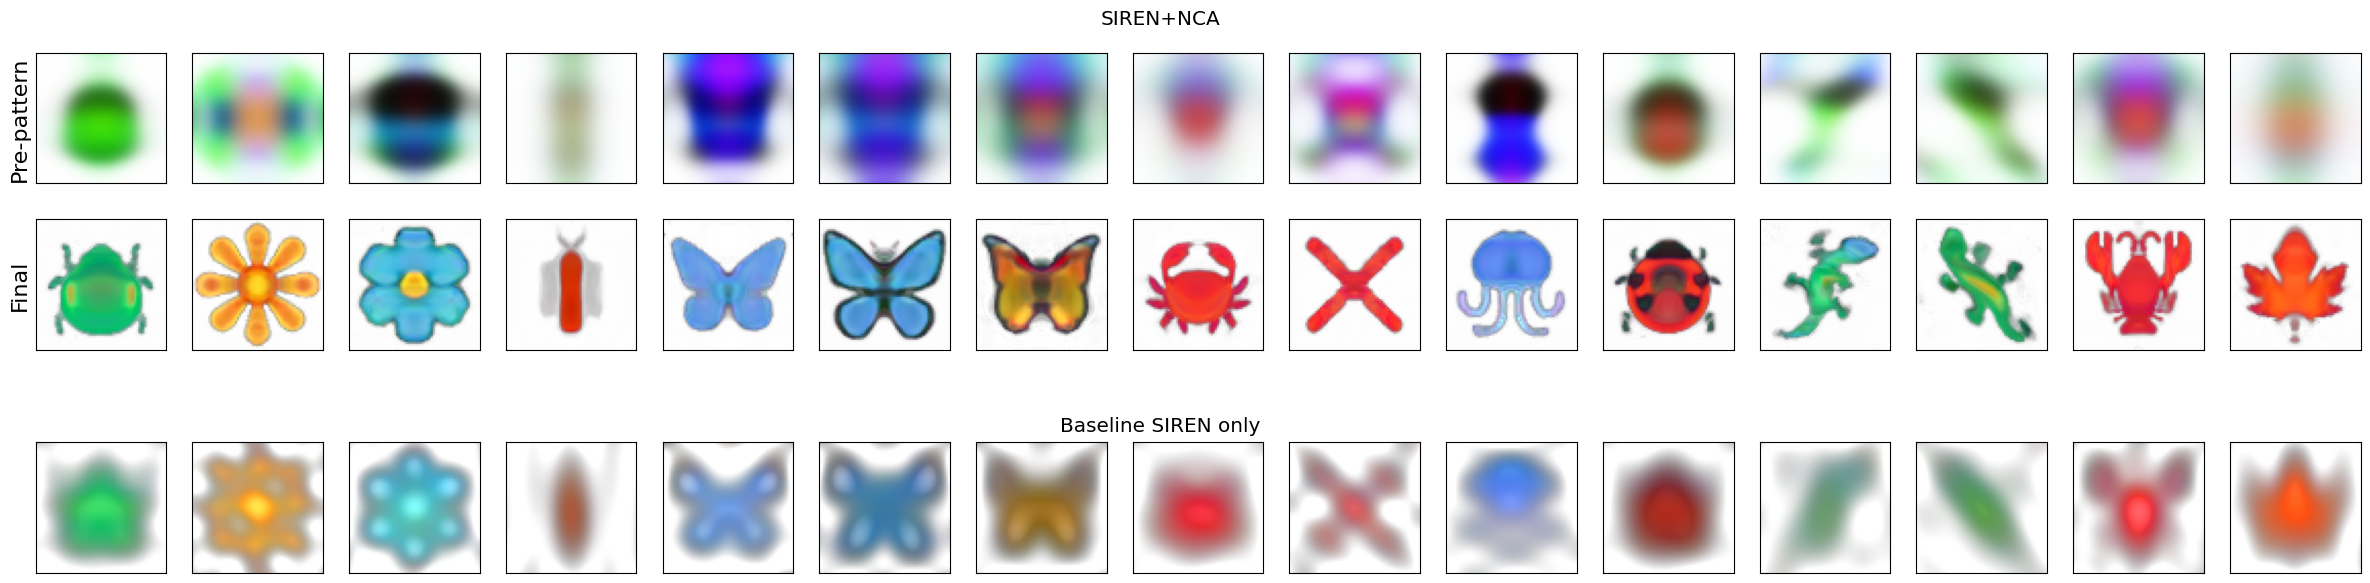

In [46]:
OUTPUT_PMNCA_TWO_ROW = Path('../figures/pmnca_three_row.svg')

_, jax_key = seed_everything(SEED)
jax_key, kp2 = jr.split(jax_key)

N_EXAMPLES = 15
n = N_EXAMPLES

inputs_a, recons_siren = get_siren_recons(SIREN_A_DIR, N_EXAMPLES, ka)
siren_init_fig1b, nca_final_fig1b = get_pmnca_siren_and_final(PMNCA_DIR, N_EXAMPLES, kp2)

fig = plt.figure(figsize=(2.0 * n, 6))
subfigs = fig.subfigures(2, 1, height_ratios=[2.1, 1], hspace=0.05)
subfigs[0].suptitle("SIREN+NCA", fontsize='x-large')
subfigs[1].suptitle("Baseline SIREN only", fontsize='x-large')

# --- Subfigure 1: pmnca results (Pre-pattern + Reconstruction) ---
axes_top = subfigs[0].subplots(2, N_EXAMPLES)
pmnca_labels = ['Pre-pattern', 'Final']

for col, (pre, final) in enumerate(zip(siren_init_fig1b, nca_final_fig1b)):
    for row_idx, img_chw in enumerate([pre, final]):
        ax = axes_top[row_idx, col]
        img = np.clip(np.asarray(img_chw), 0, 1).transpose(1, 2, 0)
        if img.shape[-1] == 4:
            alpha = img[..., 3:4]
            img = img[..., :3] * alpha + (1 - alpha)  # composite over white
        ax.imshow(img)
        strip(ax)
        if col == 0:
            ax.set_ylabel(pmnca_labels[row_idx], fontsize=16)

# --- Subfigure 2: Optimal pre-pattern ---
axes_bottom = subfigs[1].subplots(1, N_EXAMPLES)

for col, siren_opt in enumerate(recons_siren):
    ax = axes_bottom[col]
    img = np.clip(np.asarray(siren_opt), 0, 1).transpose(1, 2, 0)
    if img.shape[-1] == 4:
        alpha = img[..., 3:4]
        img = img[..., :3] * alpha + (1 - alpha)  # composite over white
    ax.imshow(img)
    strip(ax)
    # if col == 0:
    #     ax.set_ylabel('Optimal pre-pattern', fontsize=16)

OUTPUT_PMNCA_TWO_ROW.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PMNCA_TWO_ROW, bbox_inches='tight')
print(f'Figure saved to {OUTPUT_PMNCA_TWO_ROW}')
plt.show()

# Figure 3 — Robustness Analysis

## Panel 1 — Update Probability Perturbation

Load a trained PMNCA model and compare its reconstructions at the trained `update_prob` versus a modified value, to assess robustness to stochastic update rate changes.

In [75]:
# Root folder whose immediate subdirs are individual runs (each with config.json + checkpoints/)
UPDATE_PROB_CONDITION = 1.0
# UPDATE_PROB_CONDITION = 0.75
ROBUSTNESS_CONDITION_DIR = MODELS_DIR / 'noise-robust' / f'inv-pmca-up-{UPDATE_PROB_CONDITION}'
# Single run dir for a control model (any model_type); set to None to skip
# ROBUSTNESS_UPDATE_PROB   = np.linspace(0.7, 0.2, )   # update_prob to test against the trained value
ROBUSTNESS_UPDATE_PROB = np.linspace(0.25, 0.75, num=10, endpoint=False)[::-1]
ROBUSTNESS_N_EXAMPLES    = 8
OUTPUT_ROBUSTNESS        = Path(f'../figures/robustness_update_prob-{UPDATE_PROB_CONDITION}.svg')
OUTPUT_ROBUSTNESS_BAR    = Path(f'../figures/robustness_update_prob_bar-{UPDATE_PROB_CONDITION}.svg')


In [76]:
def _run_pmnca(run_dir, n, update_prob, key):
    cfg = json.loads((run_dir / 'config.json').read_text())
    jax_key, init_key, fwd_key = jr.split(key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(run_dir, abstract_model)
    if update_prob is not None:
        model = eqx.tree_at(lambda m: m.update_prob, model, update_prob)
    trained_prob = model.update_prob
    inputs = np.stack([dataset[i][0] for i in range(n)])
    eval_steps = model.num_dev_steps[-1]
    recons, _ = jax.vmap(lambda x, k: model(x, k, steps=eval_steps))(
        inputs, jr.split(fwd_key, n)
    )
    return np.asarray(inputs), np.asarray(recons).clip(0, 1), trained_prob

def per_example_mse(recons, inputs):
    return np.mean((np.asarray(recons) - np.asarray(inputs)) ** 2, axis=(1, 2, 3))


# --- collect all valid run dirs under the condition folder ---
condition_run_dirs = sorted([
    p for p in ROBUSTNESS_CONDITION_DIR.iterdir()
    if p.is_dir() and (p / 'config.json').exists()
])
print(f'Found {len(condition_run_dirs)} runs in {ROBUSTNESS_CONDITION_DIR}')

_, jax_key = seed_everything(SEED)

records = []
first_run_data = None   # store images from first run for the visual comparison

for run_dir in condition_run_dirs:
    jax_key, k_orig, k_mod = jr.split(jax_key, 3)

    inputs, recons_trained, trained_prob = _run_pmnca(
        run_dir, ROBUSTNESS_N_EXAMPLES, None, k_orig
    )
    
    mse_trained   = per_example_mse(recons_trained,  inputs)

    for i, m_t in enumerate(mse_trained):
        records.append({'run': run_dir.name, 'example_idx': i, 'mse': float(m_t),  'condition': 'trained', 'update_prob': f'p={trained_prob:.2f}'})

    for test_prob in ROBUSTNESS_UPDATE_PROB:
        _, recons_perturbed, _ = _run_pmnca(
            run_dir, ROBUSTNESS_N_EXAMPLES, test_prob, k_mod
        )
    
        mse_perturbed = per_example_mse(recons_perturbed, inputs)

        for i, m_p in enumerate(mse_perturbed):
            records.append({'run': run_dir.name, 'example_idx': i, 'mse': float(m_p),  'condition': 'perturbed', 'update_prob': f'p={test_prob:.2f}'})

df_rob = pl.DataFrame(records)
print(df_rob.head())


Found 3 runs in ../data/logs/emojis/noise-robust/inv-pmca-up-1.0
shape: (5, 5)
┌──────────────────┬─────────────┬──────────┬───────────┬─────────────┐
│ run              ┆ example_idx ┆ mse      ┆ condition ┆ update_prob │
│ ---              ┆ ---         ┆ ---      ┆ ---       ┆ ---         │
│ str              ┆ i64         ┆ f64      ┆ str       ┆ str         │
╞══════════════════╪═════════════╪══════════╪═══════════╪═════════════╡
│ 2026-04-08_14:25 ┆ 0           ┆ 0.004358 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 1           ┆ 0.004947 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 2           ┆ 0.003485 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 3           ┆ 0.004564 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 4           ┆ 0.001239 ┆ trained   ┆ p=1.00      │
└──────────────────┴─────────────┴──────────┴───────────┴─────────────┘


In [77]:
ROBUSTNESS_CONTROL_DIR = MODELS_DIR / 'noise-robust' / f'nca-{UPDATE_PROB_CONDITION}'

control_runs_dir = sorted([
    p for p in ROBUSTNESS_CONTROL_DIR.iterdir()
    if p.is_dir() and (p / 'config.json').exists()
])

print(control_runs_dir)

for run_dir in control_runs_dir:
    jax_key, k_orig, k_mod = jr.split(jax_key, 3)

    inputs, recons_trained, trained_prob = _run_pmnca(
        run_dir, ROBUSTNESS_N_EXAMPLES, None, k_orig
    )
    mse_trained   = per_example_mse(recons_trained,  inputs)

    for i, m_t in enumerate(mse_trained):
        records.append({'run': run_dir.name, 'example_idx': i, 'mse': float(m_t),  'condition': 'trained', 'update_prob': f'p={trained_prob:.2f}'})

    for test_prob in ROBUSTNESS_UPDATE_PROB:
        _, recons_perturbed, _ = _run_pmnca(
            run_dir, ROBUSTNESS_N_EXAMPLES, test_prob, k_mod
        )
    
        mse_perturbed = per_example_mse(recons_perturbed, inputs)

        for i, m_p in enumerate(mse_perturbed):
            records.append({'run': run_dir.name, 'example_idx': i, 'mse': float(m_p),  'condition': 'perturbed', 'update_prob': f'p={test_prob:.2f}'})

    # if first_run_data is None:
    #     first_run_data = (inputs, recons_trained, recons_perturbed, trained_prob)
    # print(f'  {run_dir.name}: trained={mse_trained.mean():.5f}  perturbed={mse_perturbed.mean():.5f}')


df_rob_control = pl.DataFrame(records)
print(df_rob_control.head())

[PosixPath('../data/logs/emojis/noise-robust/nca-1.0/2026-04-09_15:01'), PosixPath('../data/logs/emojis/noise-robust/nca-1.0/2026-04-09_17:45'), PosixPath('../data/logs/emojis/noise-robust/nca-1.0/2026-04-09_20:25')]
shape: (5, 5)
┌──────────────────┬─────────────┬──────────┬───────────┬─────────────┐
│ run              ┆ example_idx ┆ mse      ┆ condition ┆ update_prob │
│ ---              ┆ ---         ┆ ---      ┆ ---       ┆ ---         │
│ str              ┆ i64         ┆ f64      ┆ str       ┆ str         │
╞══════════════════╪═════════════╪══════════╪═══════════╪═════════════╡
│ 2026-04-08_14:25 ┆ 0           ┆ 0.004358 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 1           ┆ 0.004947 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 2           ┆ 0.003485 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 3           ┆ 0.004564 ┆ trained   ┆ p=1.00      │
│ 2026-04-08_14:25 ┆ 4           ┆ 0.001239 ┆ trained   ┆ p=1.00      │
└──────────────────┴─────────────┴──────────┴────

In [78]:
df_rob = df_rob.with_columns(pl.lit('SIREN+NCA').alias("model"))
df_rob_control = df_rob_control.with_columns(pl.lit('NCA').alias("model"))

df = pl.concat([df_rob, df_rob_control])

In [79]:
# --- Panel B: bar plot with mean ± std across runs ---
# Aggregate: mean MSE per (condition, run), then stats across runs
run_means = (
    df
    .group_by(['condition', 'update_prob', 'model', 'run'])
    .agg(pl.col('mse').mean().alias('mean_mse'))
)
stats = (
    run_means
    .group_by(['condition', 'update_prob', 'model'])
    .agg([
        pl.col('mean_mse').mean().alias('mean'),
        pl.col('mean_mse').std().alias('std'),
        pl.col('mean_mse').count().alias('n_runs'),
    ])
    .sort('condition', 'update_prob', descending=True)
)

# stats = stats.sort(["condition", "model"], descending=True)
print(stats)

shape: (22, 6)
┌───────────┬─────────────┬───────────┬──────────┬──────────┬────────┐
│ condition ┆ update_prob ┆ model     ┆ mean     ┆ std      ┆ n_runs │
│ ---       ┆ ---         ┆ ---       ┆ ---      ┆ ---      ┆ ---    │
│ str       ┆ str         ┆ str       ┆ f64      ┆ f64      ┆ u32    │
╞═══════════╪═════════════╪═══════════╪══════════╪══════════╪════════╡
│ trained   ┆ p=1.00      ┆ NCA       ┆ 0.003279 ┆ 0.000856 ┆ 6      │
│ trained   ┆ p=1.00      ┆ SIREN+NCA ┆ 0.00386  ┆ 0.000865 ┆ 3      │
│ perturbed ┆ p=0.70      ┆ SIREN+NCA ┆ 0.069606 ┆ 0.074668 ┆ 3      │
│ perturbed ┆ p=0.70      ┆ NCA       ┆ 0.058228 ┆ 0.048908 ┆ 6      │
│ perturbed ┆ p=0.65      ┆ NCA       ┆ 0.063377 ┆ 0.048373 ┆ 6      │
│ …         ┆ …           ┆ …         ┆ …        ┆ …        ┆ …      │
│ perturbed ┆ p=0.35      ┆ NCA       ┆ 0.156746 ┆ 0.091517 ┆ 6      │
│ perturbed ┆ p=0.30      ┆ NCA       ┆ 0.181532 ┆ 0.111335 ┆ 6      │
│ perturbed ┆ p=0.30      ┆ SIREN+NCA ┆ 0.093084 ┆ 0.079503 ┆ 

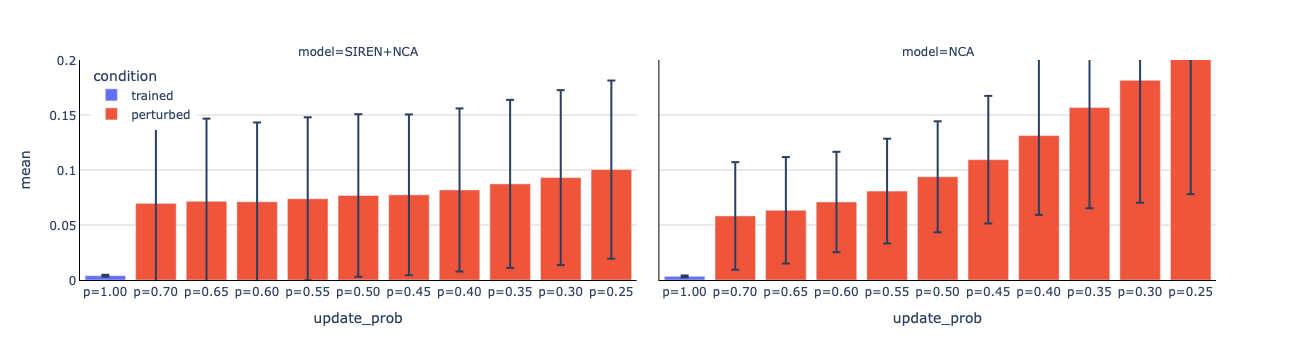

In [82]:
fig_bar = px.bar(
    data_frame=stats.sort('model', descending=True),
    x='update_prob',
    y='mean',
    error_y='std',
    facet_col='model',
    color='condition',
)

fig_bar.update_layout({
    'plot_bgcolor': 'rgba(0, 0, 0, 0)',
    'legend': {
        'yanchor': "top",
        'xanchor': "left",
        'y': 0.99,
        'x': 0.01,
    },
})

fig_bar.update_xaxes(showline=True, linewidth=1, linecolor='black')
fig_bar.update_yaxes(
    range=(0.0, 0.2),
    showline=True, 
    linewidth=1, 
    linecolor='black',
    showgrid=True, 
    gridwidth=1, 
    gridcolor='LightGrey'
)


fig_bar.write_image(OUTPUT_ROBUSTNESS_BAR, width=800, height=400)
fig_bar.show()

In [ ]:
# def show_img(ax, img_chw):
#     img = np.clip(np.asarray(img_chw), 0, 1).transpose(1, 2, 0)
#     if img.shape[-1] == 4:
#         alpha = img[..., 3:4]
#         img = img[..., :3] * alpha + (1 - alpha)
#     ax.imshow(img)
#     strip(ax)


# # --- Panel A: image comparison (first run) ---
# inputs_vis, recons_tr_vis, recons_pt_vis, trained_prob = first_run_data
# n = ROBUSTNESS_N_EXAMPLES

# row_labels = [
#     'Ground truth',
#     f'Trained (p={trained_prob:.2f})',
#     f'Perturbed (p={ROBUSTNESS_UPDATE_PROB:.2f})',
# ]
# fig_img, axes_img = plt.subplots(3, n, figsize=(2.0 * n, 6.5))
# for col in range(n):
#     for row_idx, imgs in enumerate([inputs_vis, recons_tr_vis, recons_pt_vis]):
#         ax = axes_img[row_idx, col]
#         show_img(ax, imgs[col])
#         if col == 0:
#             ax.set_ylabel(row_labels[row_idx], fontsize=12)

# fig_img.tight_layout()
# OUTPUT_ROBUSTNESS.parent.mkdir(parents=True, exist_ok=True)
# # fig_img.savefig(OUTPUT_ROBUSTNESS, bbox_inches='tight')
# # print(f'Image comparison saved to {OUTPUT_ROBUSTNESS}')
# plt.show()

## Pre-patterns at different levels of noise

In [85]:
OUTPUT_PMNCA_UP_COMP = Path('../figures/update_prob_comp.svg')
PMNCA_DIR_075 = [p for p in (MODELS_DIR / 'noise-robust' / 'inv-pmca-up-0.75').iterdir() if p.is_dir() and (p / 'config.json').exists()]
PMNCA_DIR_100 = [p for p in (MODELS_DIR / 'noise-robust' / 'inv-pmca-up-1.0').iterdir() if p.is_dir() and (p / 'config.json').exists()]


N_EXAMPLES = 10
pmca_up_075 = get_pmnca_siren_and_final(PMNCA_DIR_075[0], N_EXAMPLES, kp)
pmca_up_100 = get_pmnca_siren_and_final(PMNCA_DIR_100[1], N_EXAMPLES, kp)

Figure saved to ../figures/update_prob_comp.svg


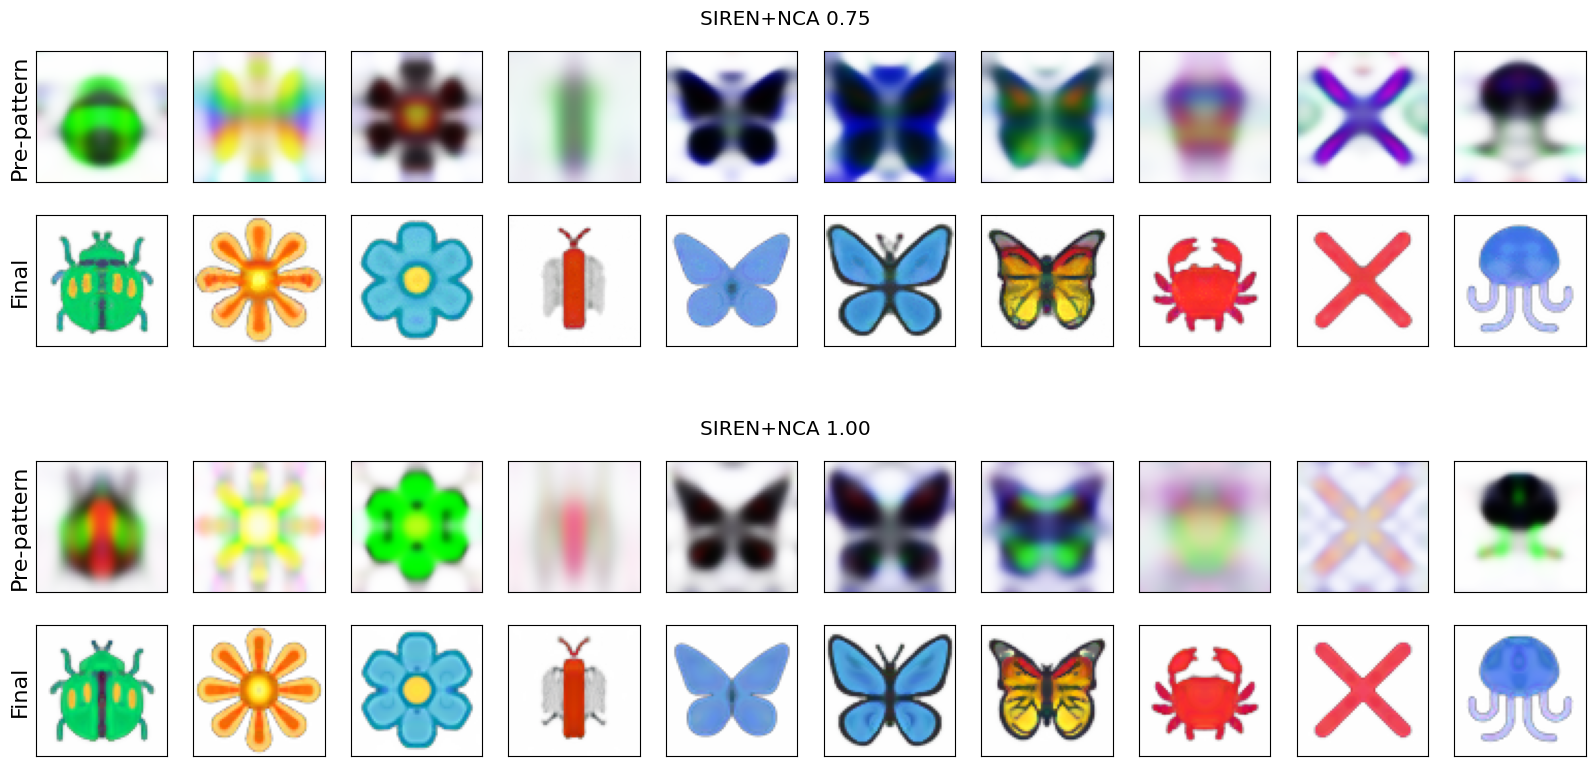

In [86]:
# OUTPUT_PMNCA_TWO_ROW = Path('../figures/pmnca_three_row.svg')

_, jax_key = seed_everything(SEED)
jax_key, kp2 = jr.split(jax_key)

n = N_EXAMPLES

fig = plt.figure(figsize=(2.0 * n, 8))
subfigs = fig.subfigures(2, 1, height_ratios=[1, 1], hspace=0.05)
subfigs[0].suptitle("SIREN+NCA 0.75", fontsize='x-large')
subfigs[1].suptitle("SIREN+NCA 1.00", fontsize='x-large')

# --- Subfigure 1: pmnca results (Pre-pattern + Reconstruction) ---
pmnca_labels = ['Pre-pattern', 'Final']

for row, (siren_init_p, nca_final_p) in enumerate([pmca_up_075, pmca_up_100]):
    axes = subfigs[row].subplots(2, N_EXAMPLES)
    for col, (pre, final) in enumerate(zip(siren_init_p, nca_final_p)):
        for row_idx, img_chw in enumerate([pre, final]):
            ax = axes[row_idx, col]
            img = np.clip(np.asarray(img_chw), 0, 1).transpose(1, 2, 0)
            if img.shape[-1] == 4:
                alpha = img[..., 3:4]
                img = img[..., :3] * alpha + (1 - alpha)  # composite over white
            ax.imshow(img)
            strip(ax)
            if col == 0:
                ax.set_ylabel(pmnca_labels[row_idx], fontsize=16)


OUTPUT_PMNCA_UP_COMP.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PMNCA_UP_COMP, bbox_inches='tight')
print(f'Figure saved to {OUTPUT_PMNCA_UP_COMP}')
plt.show()

# Figure 4 — Capacity Analysis


In [5]:
# CAPACITY_DIRS maps n_patterns (int) → parent folder containing seed run subdirs
# Each seed subdir must have config.json + checkpoints/

CAPACITY_DIRS = {
    1: {
        'nca': MODELS_DIR / 'capacity' / 'nca-beetle',
        'siren+nca': MODELS_DIR / 'capacity' / 'inv-pmca-beetle',
    },
    2: {
        'nca': MODELS_DIR / 'capacity' / 'nca-beetle blossom',
        'siren+nca': MODELS_DIR / 'capacity' / 'inv-pmca-beetle blossom',
    },
    4: {
        'nca': MODELS_DIR / 'capacity' / 'nca-beetle blossom lady_beetle butterfly_b',
        'siren+nca': MODELS_DIR / 'capacity' / 'inv-pmca-beetle blossom lady_beetle butterfly_b',
    },
    8: {
        'nca': MODELS_DIR / 'capacity' / 'nca-beetle blossom lady_beetle butterfly_b crab jellyfish lobster mushroom',
        'siren+nca': MODELS_DIR / 'capacity' / 'inv-pmca-beetle blossom lady_beetle butterfly_b crab jellyfish lobster mushroom',
    },
    16: {
        'nca': MODELS_DIR / 'capacity' / 'nca-beetle blossom butterfly_b butterfly_c crab cross jellyfish lady_beetle lizard lobster mushroom maple_leaf microbe snowflake squid star',
        'siren+nca': MODELS_DIR / 'capacity' / 'inv-pmca-beetle blossom butterfly_b butterfly_c crab cross jellyfish lady_beetle lizard lobster mushroom maple_leaf microbe snowflake squid star',
    }
}
OUTPUT_CAPACITY = Path('../figures/capacity_analysis.svg')

In [14]:
_, jax_key = seed_everything(SEED)

cap_records = []


for n_patterns, model_dir in CAPACITY_DIRS.items():
    for _, parent_dir in sorted(model_dir.items()):
        run_dirs = sorted([
            p for p in parent_dir.iterdir()
            if p.is_dir() and (p / 'config.json').exists()
        ])
        print(f'n_patterns={n_patterns}: found {len(run_dirs)} runs in {parent_dir}')
    
        for run_dir in tqdm(run_dirs, desc=f'  n={n_patterns}', leave=False):
            cfg = json.loads((run_dir / 'config.json').read_text())
            model_type = cfg.get('model_type', 'siren')
    
            emoji_names = cfg.get('emoji_names')
            if emoji_names is None:
                print(f'  [SKIP] {run_dir.name}: no emoji_names in config (model_type={model_type})')
                continue
    
            jax_key, init_key, eval_key = jr.split(jax_key, 3)
            abstract_model, _ = init_model(cfg, init_key)
    
            try:
                model = load_best_checkpoint(run_dir, abstract_model)
            except Exception as e:
                print(f'  [SKIP] {run_dir.name}: checkpoint load failed ({e})')
                continue
    
            trained_dataset = EmojiDataset(
                '../data/datasets/emojis',
                emoji_names,
                (cfg['input_size'], cfg['input_size']),
                (cfg['padding'], cfg['padding']),
            )
    
            mse = compute_test_mse(model, trained_dataset, model_type, eval_key)
            cap_records.append({
                'model_type': model_type,
                'n_patterns': n_patterns,
                'mse': mse,
                'run': run_dir.name,
            })
            print(f'    {run_dir.name} ({model_type}, n={n_patterns}): MSE={mse:.6f}')
    
    print(f'\nCollected {len(cap_records)} records.')

n_patterns=1: found 3 runs in ../data/logs/emojis/capacity/nca-beetle


  n=1:   0%|                                                                                                                                                                                                    | 0/3 [00:00<?, ?it/s]

  [SKIP] 2026-04-08_16:07: checkpoint load failed (Requested shape: (4,) is not compatible with the stored shape: (16,). Truncating/padding is disabled. To enable it, set `strict=False` in `ArrayRestoreArgs` for any array in v0 API or `enable_padding_and_truncation=True` in `ArrayOptions.Loading` in v1 API.)


  n=1:  67%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                              | 2/3 [00:01<00:00,  1.25it/s]

    2026-04-09_17:46 (nca, n=1): MSE=32.329720


...

  n=16:  33%|██████████████████████████████████████████████████████████████▎                                                                                                                            | 1/3 [00:02<00:04,  2.49s/it]

    2026-04-10_09:51 (pmnca, n=16): MSE=148.517293


  n=16:  67%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                              | 2/3 [00:04<00:02,  2.48s/it]

    2026-04-10_10:45 (pmnca, n=16): MSE=163.507320


    2026-04-10_11:39 (pmnca, n=16): MSE=95.294944

Collected 26 records.


In [15]:
df_cap = pl.DataFrame(cap_records)

run_means = (
    df_cap
    .group_by(['model_type', 'n_patterns', 'run'])
    .agg(pl.col('mse').mean().alias('mean_mse'))
)
cap_stats = (
    run_means
    .group_by(['model_type', 'n_patterns'])
    .agg([
        pl.col('mean_mse').mean().alias('mean'),
        pl.col('mean_mse').std().alias('std'),
        pl.col('mean_mse').count().alias('n_runs'),
    ])
    .sort(['n_patterns', 'model_type'])
)
print(cap_stats)

shape: (10, 5)
┌────────────┬────────────┬────────────┬───────────┬────────┐
│ model_type ┆ n_patterns ┆ mean       ┆ std       ┆ n_runs │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---    │
│ str        ┆ i64        ┆ f64        ┆ f64       ┆ u32    │
╞════════════╪════════════╪════════════╪═══════════╪════════╡
│ nca        ┆ 1          ┆ 30.561202  ┆ 2.501061  ┆ 2      │
│ pmnca      ┆ 1          ┆ 4.399856   ┆ 1.834648  ┆ 3      │
│ nca        ┆ 2          ┆ 51.358994  ┆ 2.375005  ┆ 2      │
│ pmnca      ┆ 2          ┆ 9.394073   ┆ 3.739046  ┆ 3      │
│ nca        ┆ 4          ┆ 79.853271  ┆ 8.148581  ┆ 2      │
│ pmnca      ┆ 4          ┆ 32.188606  ┆ 3.721611  ┆ 3      │
│ nca        ┆ 8          ┆ 148.716923 ┆ 37.347696 ┆ 2      │
│ pmnca      ┆ 8          ┆ 57.801601  ┆ 18.085547 ┆ 3      │
│ nca        ┆ 16         ┆ 217.613146 ┆ 2.515778  ┆ 3      │
│ pmnca      ┆ 16         ┆ 135.773186 ┆ 35.847472 ┆ 3      │
└────────────┴────────────┴────────────┴───────────┴───

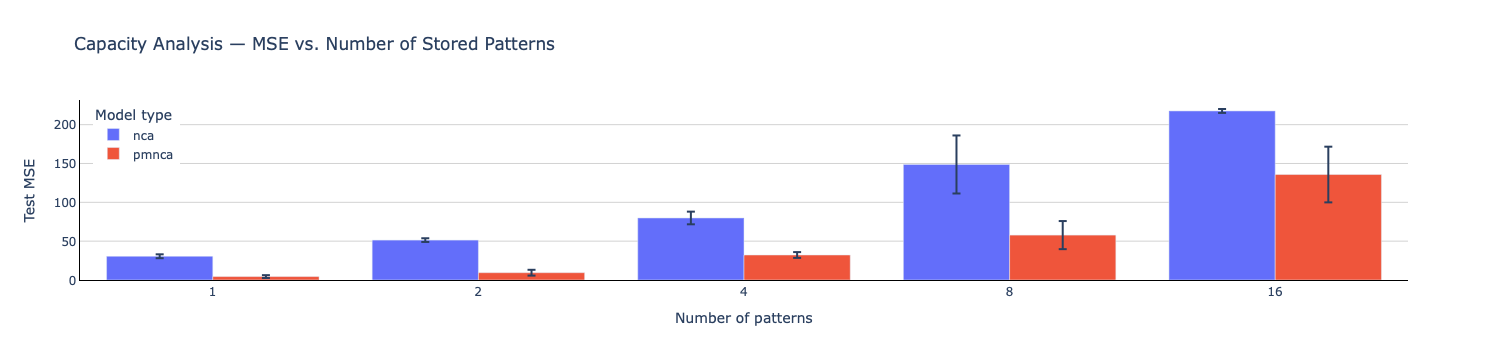

In [34]:
fig_cap = px.bar(
    data_frame=cap_stats,
    x='n_patterns',
    y='mean',
    error_y='std',
    color='model_type',
    barmode='group',
    labels={
        'n_patterns': 'Number of patterns',
        'mean': 'Test MSE',
        'model_type': 'Model type',
    },
    title='Capacity Analysis — MSE vs. Number of Stored Patterns',
)

fig_cap.update_layout({
    'plot_bgcolor': 'rgba(0, 0, 0, 0)',
    'legend': {
        'yanchor': "top",
        'xanchor': "left",
        'y': 0.99,
        'x': 0.01,
    },
})
fig_cap.update_xaxes(
    showline=True, linewidth=1, linecolor='black',
    type='category',
)
fig_cap.update_yaxes(
    showline=True, linewidth=1, linecolor='black',
    showgrid=True, gridwidth=1, gridcolor='LightGray',
)

OUTPUT_CAPACITY.parent.mkdir(parents=True, exist_ok=True)
fig_cap.write_image(OUTPUT_CAPACITY, width=600, height=400)
fig_cap.show()

# Figure 5 — SIREN Noise Robustness

Load one or more trained PMNCA models and evaluate how well the NCA recovers
from Gaussian noise injected into the SIREN pattern at inference time.
For each noise level $\sigma$ the signal-to-noise ratio (SNR) of the corrupted
pattern is computed as

$$\mathrm{SNR}(\sigma) = 10 \log_{10}\!\left(\frac{\mathbb{E}[s^2]}{\sigma^2}\right) \quad (\mathrm{dB})$$

where $s$ is the clean SIREN output (obtained with $\sigma=0$).
The plot shows per-example MSE of the final NCA output vs. SNR.

In [67]:
# One entry per model to compare; each path must contain config.json + checkpoints/
SIREN_NOISE_DIRS = [
    MODELS_DIR.parent / 'siren_noise' / 'inv-pmnca_0.05',   
    MODELS_DIR.parent / 'siren_noise' / 'inv-pmnca_0.1',
    MODELS_DIR.parent / 'siren_noise' / 'inv-pmnca_0.15',   
]
SIREN_NOISE_DIRS = [fld for model_dir in SIREN_NOISE_DIRS for fld in model_dir.iterdir() if fld.is_dir()]
print(SIREN_NOISE_DIRS)

# SIREN_NOISE_LABELS = [x'0.1']

NOISE_STD_VALUES  = np.logspace(-3, 0.5, 30)   # inference-time noise stds to sweep
NOISE_N_EXAMPLES  = 16
OUTPUT_NOISE_ROB  = Path('../figures/siren_noise_robustness.svg')

[PosixPath('../data/logs/siren_noise/inv-pmnca_0.05/2026-04-12_18-30'), PosixPath('../data/logs/siren_noise/inv-pmnca_0.05/2026-04-12_17-28'), PosixPath('../data/logs/siren_noise/inv-pmnca_0.1/2026-04-12_18:22'), PosixPath('../data/logs/siren_noise/inv-pmnca_0.1/2026-04-12_20:03'), PosixPath('../data/logs/siren_noise/inv-pmnca_0.15/2026-04-12_20:53'), PosixPath('../data/logs/siren_noise/inv-pmnca_0.15/2026-04-12_19:13')]


In [96]:
_, jax_key = seed_everything(SEED)

noise_curves = []   # list of {'label', 'trained_noise_std', 'snr_db', 'mse', 'mse_clean'}

for model_dir in tqdm(SIREN_NOISE_DIRS, desc='models'):
    cfg = json.loads((model_dir / 'config.json').read_text())
    trained_std = cfg.get('siren_noise_std', 0.0)
    # print(cfg)

    jax_key, init_key, clean_key = jr.split(jax_key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(model_dir, abstract_model)

    inputs = np.stack([dataset[i][0] for i in range(NOISE_N_EXAMPLES)])
    C = inputs.shape[1]
    eval_steps = model.num_dev_steps[-1]

    # Clean pass — used to establish signal power and baseline MSE
    clean_recons, clean_dev = jax.vmap(
        lambda x, k: model(x, k, steps=eval_steps, siren_noise_std=0.0)
    )(inputs, jr.split(clean_key, NOISE_N_EXAMPLES))
    clean_siren  = np.asarray(clean_dev[:, 0, :C])          # (N, C, H, W)
    signal_power = float(np.mean(clean_siren ** 2))
    mse_clean    = float(np.sum((np.asarray(clean_recons) - inputs) ** 2) / len(clean_recons))

    for noise_std in tqdm(NOISE_STD_VALUES, leave=False, desc='noise sweep'):
        jax_key, step_key = jr.split(jax_key)
        recons, _ = jax.vmap(
            lambda x, k: model(x, k, steps=eval_steps, siren_noise_std=float(noise_std))
        )(inputs, jr.split(step_key, NOISE_N_EXAMPLES))
        mse = float(np.sum((np.asarray(recons) - inputs) ** 2) / len(clean_recons))
        snr_db = 10.0 * np.log10(signal_power / noise_std ** 2)

        noise_curves.append({
            'run': model_dir.name,
            'label': f'σ_train={trained_std:.3g}',
            'trained_noise_std': trained_std,
            'test_noise': noise_std,
            'snr_db':  float(snr_db),
            'mse':     mse,
            'mse_clean': mse_clean,
            'signal_power': signal_power,
        })
    print(f'{model_dir.name}  σ_train={trained_std:.3g}  mse_clean={mse_clean:.5f}')

models:  17%|███████████████████████████████▏                                                                                                                                                           | 1/6 [00:16<01:23, 16.60s/it]

2026-04-12_18-30  σ_train=0.05  mse_clean=53.13248



models:  33%|██████████████████████████████████████████████████████████████▎                                                                                                                            | 2/6 [00:33<01:06, 16.66s/it]

2026-04-12_17-28  σ_train=0.05  mse_clean=42.47069



models:  50%|█████████████████████████████████████████████████████████████████████████████████████████████▌                                                                                             | 3/6 [00:49<00:49, 16.65s/it]

...

2026-04-12_20:03  σ_train=0.1  mse_clean=53.96427



models:  83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                               | 5/6 [01:22<00:16, 16.52s/it]

2026-04-12_20:53  σ_train=0.15  mse_clean=102.45215



models: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:39<00:00, 16.54s/it]

2026-04-12_19:13  σ_train=0.15  mse_clean=49.40628


In [100]:
df = pl.DataFrame(noise_curves)
df.head()

run,label,trained_noise_std,test_noise,snr_db,mse,mse_clean,signal_power
str,str,f64,f64,f64,f64,f64,f64
"""2026-04-12_18-30""","""σ_train=0.05""",0.05,0.001,56.18683,53.122616,53.132484,0.415607
"""2026-04-12_18-30""","""σ_train=0.05""",0.05,0.00132,53.773036,53.124531,53.132484,0.415607
"""2026-04-12_18-30""","""σ_train=0.05""",0.05,0.001743,51.359243,53.165257,53.132484,0.415607
"""2026-04-12_18-30""","""σ_train=0.05""",0.05,0.002302,48.94545,53.187157,53.132484,0.415607
"""2026-04-12_18-30""","""σ_train=0.05""",0.05,0.003039,46.531657,53.080727,53.132484,0.415607


In [107]:
# --- Panel B: bar plot with mean ± std across runs ---
# Aggregate: mean MSE per (condition, run), then stats across runs
run_means = (
    df
    .group_by(['trained_noise_std', 'test_noise', 'run'])
    .agg(pl.col('mse').mean().alias('mean_mse'))
)
stats = (
    run_means
    .group_by(['trained_noise_std', 'test_noise', 'run'])
    .agg([
        pl.col('mean_mse').mean().alias('mean'),
        pl.col('mean_mse').std().alias('std'),
    ]).sort('trained_noise_std', 'test_noise')
)

# stats = stats.sort(["condition", "model"], descending=True)
print(stats)

shape: (180, 5)
┌───────────────────┬────────────┬──────────────────┬─────────────┬──────┐
│ trained_noise_std ┆ test_noise ┆ run              ┆ mean        ┆ std  │
│ ---               ┆ ---        ┆ ---              ┆ ---         ┆ ---  │
│ f64               ┆ f64        ┆ str              ┆ f64         ┆ f64  │
╞═══════════════════╪════════════╪══════════════════╪═════════════╪══════╡
│ 0.05              ┆ 0.001      ┆ 2026-04-12_17-28 ┆ 42.482086   ┆ null │
│ 0.05              ┆ 0.001      ┆ 2026-04-12_18-30 ┆ 53.122616   ┆ null │
│ 0.05              ┆ 0.00132    ┆ 2026-04-12_17-28 ┆ 42.469868   ┆ null │
│ 0.05              ┆ 0.00132    ┆ 2026-04-12_18-30 ┆ 53.124531   ┆ null │
│ 0.05              ┆ 0.001743   ┆ 2026-04-12_18-30 ┆ 53.165257   ┆ null │
│ …                 ┆ …          ┆ …                ┆ …           ┆ …    │
│ 0.15              ┆ 1.813931   ┆ 2026-04-12_19:13 ┆ 2659.205566 ┆ null │
│ 0.15              ┆ 2.395027   ┆ 2026-04-12_20:53 ┆ 2712.818848 ┆ null │
│ 0.15   

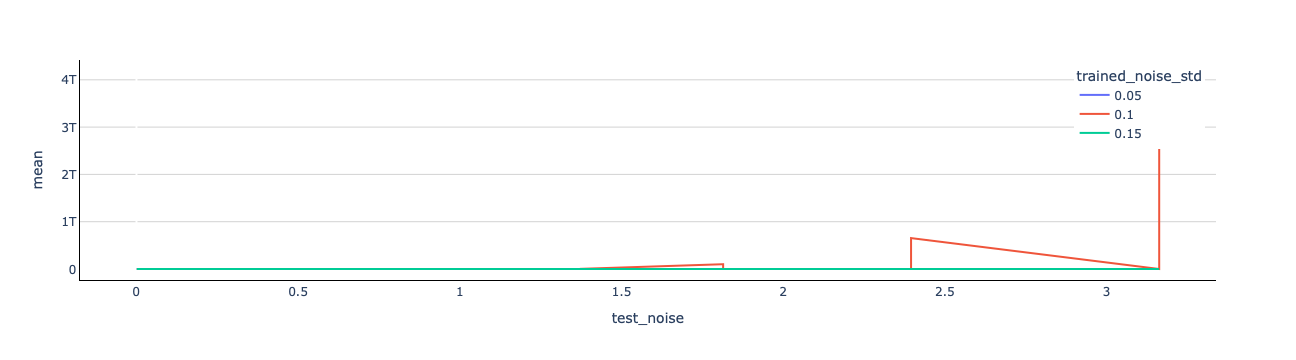

In [109]:
fig_bar = px.line(
    data_frame=stats,
    x='test_noise',
    y='mean',
    error_y='std',
    color='trained_noise_std',
)

fig_bar.update_layout({
    'plot_bgcolor': 'rgba(0, 0, 0, 0)',
    'legend': {
        'yanchor': "top",
        'xanchor': "right",
        'y': 0.99,
        'x': 0.99,
    },
})

fig_bar.update_xaxes(showline=True, linewidth=1, linecolor='black')
fig_bar.update_yaxes(
    # range=(0.0, 0.2),
    showline=True, 
    linewidth=1, 
    linecolor='black',
    showgrid=True, 
    gridwidth=1, 
    gridcolor='LightGrey'
)


# fig_bar.write_image(OUTPUT_ROBUSTNESS_BAR, width=800, height=400)
fig_bar.show()

# Figure 6 — Growth Development

Shows how the model develops from an initial seed patch across evenly-spaced time steps.
Each row is one example; each column is a snapshot in time (step 0 always included).

In [48]:
def get_growth_snapshots(run_dir: Path, examples: list[int], n_steps: int, key: jax.Array):
    """Run n examples through a growing model and return evenly-spaced snapshots.

    Parameters
    ----------
    run_dir : Path
        Model run directory (must contain config.json + checkpoints/).
    n : int
        Number of dataset examples to run.
    n_steps : int
        Number of time snapshots to keep (step 0 is always included).
    key : jax.Array
        JAX random key.

    Returns
    -------
    inputs : np.ndarray  shape (n, C, H, W)
    snapshots : np.ndarray  shape (n, n_steps, C, H, W)
    step_indices : list[int]  the T indices that were selected
    """
    cfg = json.loads((run_dir / 'config.json').read_text())
    jax_key, init_key, fwd_key = jr.split(key, 3)
    abstract_model, dataset = init_model(cfg, init_key)
    model = load_best_checkpoint(run_dir, abstract_model)

    n = len(examples)
    eval_steps = model.num_dev_steps[-1]
    inputs = np.stack([dataset[i][0] for i in examples])
    C = inputs.shape[1]

    _, dev_paths = jax.vmap(lambda x, k: model(x, k, steps=eval_steps))(
        inputs, jr.split(fwd_key, n)
    )
    # dev_paths: (n, T+1, state_size, H, W)
    T = dev_paths.shape[1] - 1
    step_indices = np.linspace(0, T, n_steps, dtype=int).tolist()
    snapshots = np.asarray(dev_paths[:, step_indices, :C])  # (n, n_steps, C, H, W)
    return np.asarray(inputs), snapshots, step_indices

In [78]:
# Path to a growing SIREN-NCA run (must contain config.json + checkpoints/)
GROWING_DIR    = MODELS_DIR / 'growing-pmca-2' / '2026-02-22_11:28'
EXAMPLES = [0, 2, 5, 9]
OUTPUT_GROWTH  = Path('../figures/growth_development.svg')
N_EXAMPLES     = len(EXAMPLES)  # rows in the figure
N_STEPS        = 8   # columns (time snapshots), always includes step 0

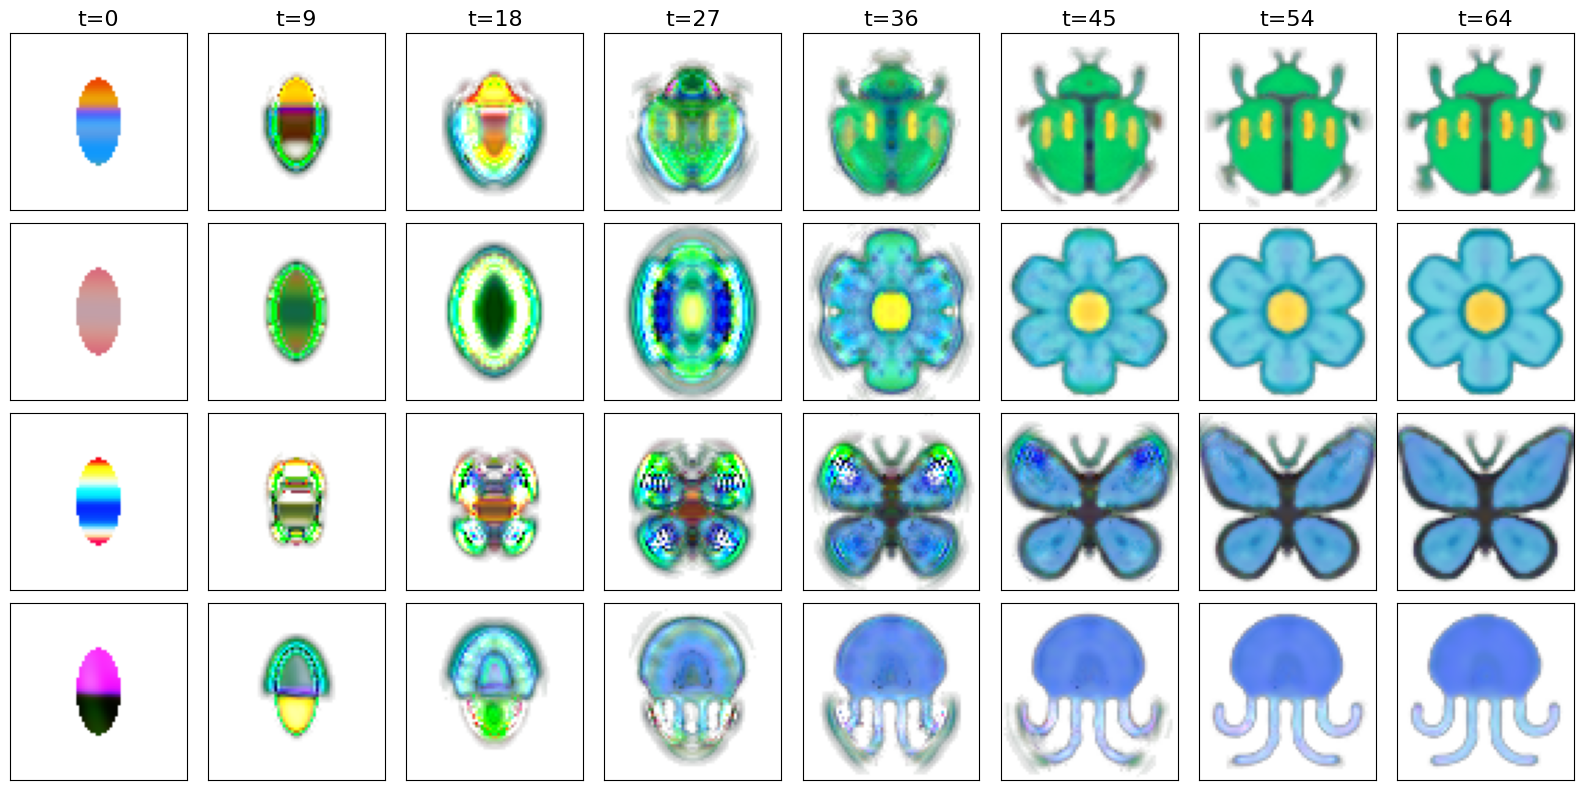

In [79]:
def show_img(ax, img_chw):
    img = np.clip(np.asarray(img_chw), 0, 1).transpose(1, 2, 0)
    if img.shape[-1] == 4:
        alpha = img[..., 3:4]
        img = img[..., :3] * alpha + (1 - alpha)
    ax.imshow(img)
    strip(ax)


_, jax_key = seed_everything(SEED)
jax_key, kg = jr.split(jax_key)

inputs_g, snapshots_g, step_indices_g = get_growth_snapshots(
    GROWING_DIR, EXAMPLES, N_STEPS, kg
)

fig, axes = plt.subplots(
    N_EXAMPLES, N_STEPS,
    figsize=(2.0 * N_STEPS, 2.0 * N_EXAMPLES),
    squeeze=False,
)

for col, step in enumerate(step_indices_g):
    axes[0, col].set_title(f't={step}', fontsize=16)

for row in range(N_EXAMPLES):
    for col in range(N_STEPS):
        show_img(axes[row, col], snapshots_g[row, col])

fig.tight_layout()
OUTPUT_GROWTH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_GROWTH, bbox_inches='tight')
plt.show()